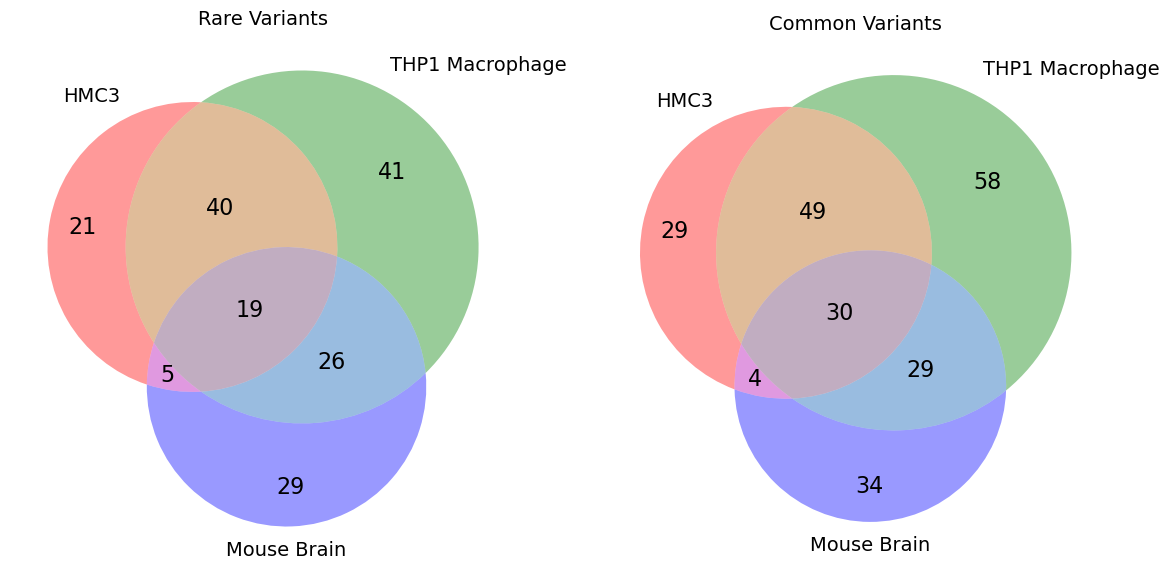

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Dictionary to map filename -> label
label_dic = {    
    'annotated_20240812_comparative_HMC3_alleleOnly.csv': 'HMC3',
    'annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv': 'THP1 Monocyte',
    'annotated_20240719_comparative_HEK293T_alleleOnly.csv': 'HEK293T',
    'annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv': 'THP1 Macrophage',
    'annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv': 'Mouse Brain',
}

annot_files = [
    'annotated_20240812_comparative_HMC3_alleleOnly.csv',
    'annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv',
    'annotated_20240719_comparative_HEK293T_alleleOnly.csv',
    'annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv',
    'annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',
]


sets_condition = {}

# Initialize empty sets for each condition in label_dic
for fname, condition_label in label_dic.items():
    sets_condition[condition_label] = {"Rare": set(), "Common": set()}

# Loop through all files, filter out significant alt rows, collect RSIDs
for fname in annot_files:
    if fname not in label_dic:
        continue
    
    condition_label = label_dic[fname]
    
    # Read in the CSV
    fpath = os.path.join('allele_differences_withoutcontrol/20240817_allele_only_for_plotting', fname)
    df = pd.read_csv(fpath, index_col=0)
    
    # Filter for "alt" rows
    df = df[df.index.str.startswith('alt')]
    
    # Normalize and filter significance
    df["logFC_norm"] = df["logFC"] / df["logFC"].std()
    df_sig = df[(df["fdr"] <= 0.05) & (df["logFC_norm"].abs() >= 0)]
    
    # For each significant row, add its RSID to Rare or Common set
    for _, row in df_sig.iterrows():
        rc = row["Rare_Low_Common"]  # "Rare" or "Common"
        rsid = row["RSID"]
        if rc in ["Rare", "Common"]:  # Just a safeguard
            sets_condition[condition_label][rc].add(rsid)

# Now we have sets of RSIDs for each condition, separated into Rare vs. Common
# We only need HMC3, THP1 Macrophage, and Mouse Brain in the final Venns
cond_names = ["HMC3", "THP1 Macrophage", "Mouse Brain"]

# Prepare the figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --------------------------
# Venn #1: Rare Overlaps
# --------------------------
v = venn3(
    [
        sets_condition["HMC3"]["Rare"],
        sets_condition["THP1 Macrophage"]["Rare"],
        sets_condition["Mouse Brain"]["Rare"]
    ],
    set_labels=("HMC3", "THP1 Macrophage", "Mouse Brain"),
    ax=axes[0]
)
axes[0].set_title("Rare Variants",fontsize=14)
# Increase the font size of the subset (numbers in circles) labels
for subset_label in v.subset_labels:
    if subset_label:  # check for None
        subset_label.set_fontsize(16)

# If you want to increase the size of the set labels too:
for set_label in v.set_labels:
    if set_label:  
        set_label.set_fontsize(14)
# --------------------------
# Venn #2: Common Overlaps
# --------------------------
v = venn3(
    [
        sets_condition["HMC3"]["Common"],
        sets_condition["THP1 Macrophage"]["Common"],
        sets_condition["Mouse Brain"]["Common"]
    ],
    set_labels=("HMC3", "THP1 Macrophage", "Mouse Brain"),
    ax=axes[1]
)
axes[1].set_title("Common Variants",fontsize=14)
# Increase the font size of the subset (numbers in circles) labels
for subset_label in v.subset_labels:
    if subset_label:  # check for None
        subset_label.set_fontsize(16)

# If you want to increase the size of the set labels too:
for set_label in v.set_labels:
    if set_label:  
        set_label.set_fontsize(14)
plt.tight_layout()
plt.savefig('venn_common_rare_new.pdf', format='pdf', dpi=300)  # Adjust dpi for higher or lower resolution
plt.show()


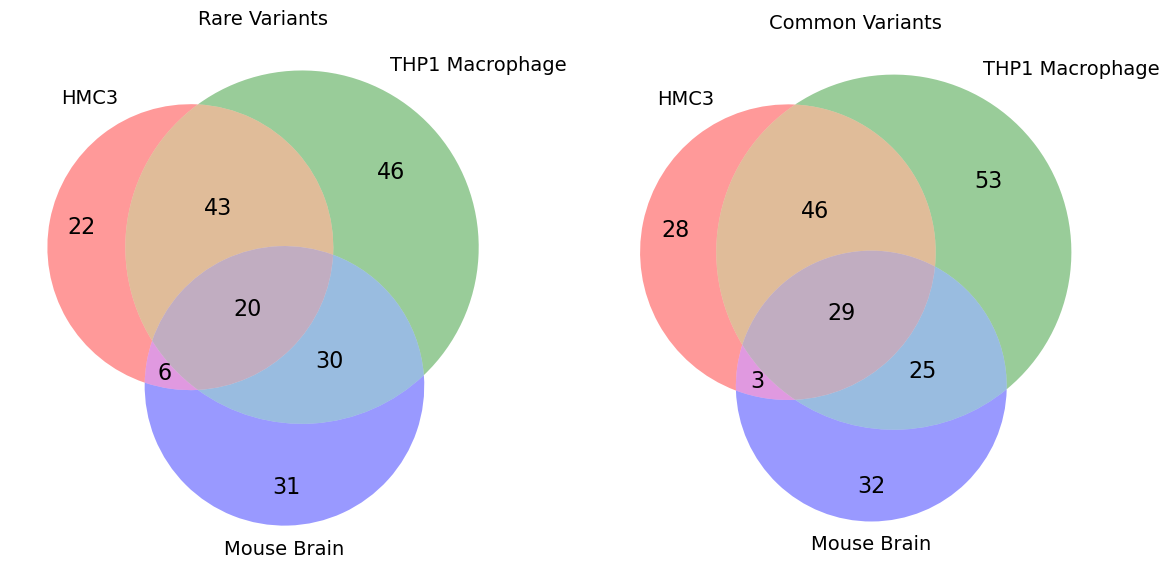

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Dictionary to map filename -> label
label_dic = {    
    'annotated_20240812_comparative_HMC3_alleleOnly.csv': 'HMC3',
    'annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv': 'THP1 Monocyte',
    'annotated_20240719_comparative_HEK293T_alleleOnly.csv': 'HEK293T',
    'annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv': 'THP1 Macrophage',
    'annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv': 'Mouse Brain',
}

annot_files = [
    'annotated_20240812_comparative_HMC3_alleleOnly.csv',
    'annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv',
    'annotated_20240719_comparative_HEK293T_alleleOnly.csv',
    'annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv',
    'annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',
]

sets_condition = {}

# Initialize empty sets for each condition in label_dic
for fname, condition_label in label_dic.items():
    sets_condition[condition_label] = {"Rare": set(), "Common": set()}

# Loop through all files, filter out significant alt rows, collect RSIDs
for fname in annot_files:
    if fname not in label_dic:
        continue
    
    condition_label = label_dic[fname]
    
    # Read in the CSV
    fpath = os.path.join('allele_differences_withoutcontrol/20240817_allele_only_for_plotting', fname)
    df = pd.read_csv(fpath, index_col=0)
    
    # Filter for "alt" rows
    df = df[df.index.str.startswith('alt')]
    
    # Normalize and filter significance
    df["logFC_norm"] = df["logFC"] / df["logFC"].std()
    df_sig = df[(df["fdr"] <= 0.05) & (df["logFC_norm"].abs() >= 0)]
    
    # For each significant row, add its RSID to Rare or Common set
    for _, row in df_sig.iterrows():
        rc = row["Rare_Low_Common"]  # "Rare" or "Common"
        if rc == 'Low Frequency':
            rc = 'Rare'
        rsid = row["RSID"]
        if rc in ["Rare", "Common"]:  # Just a safeguard
            sets_condition[condition_label][rc].add(rsid)


# Now we have sets of RSIDs for each condition, separated into Rare vs. Common
# We only need HMC3, THP1 Macrophage, and Mouse Brain in the final Venns
cond_names = ["HMC3", "THP1 Macrophage", "Mouse Brain"]

# Prepare the figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --------------------------
# Venn #1: Rare Overlaps
# --------------------------
v = venn3(
    [
        sets_condition["HMC3"]["Rare"],
        sets_condition["THP1 Macrophage"]["Rare"],
        sets_condition["Mouse Brain"]["Rare"]
    ],
    set_labels=("HMC3", "THP1 Macrophage", "Mouse Brain"),
    ax=axes[0]
)
axes[0].set_title("Rare Variants",fontsize=14)
# Increase the font size of the subset (numbers in circles) labels
for subset_label in v.subset_labels:
    if subset_label:  # check for None
        subset_label.set_fontsize(16)

# If you want to increase the size of the set labels too:
for set_label in v.set_labels:
    if set_label:  
        set_label.set_fontsize(14)
# --------------------------
# Venn #2: Common Overlaps
# --------------------------
v = venn3(
    [
        sets_condition["HMC3"]["Common"],
        sets_condition["THP1 Macrophage"]["Common"],
        sets_condition["Mouse Brain"]["Common"]
    ],
    set_labels=("HMC3", "THP1 Macrophage", "Mouse Brain"),
    ax=axes[1]
)
axes[1].set_title("Common Variants",fontsize=14)
# Increase the font size of the subset (numbers in circles) labels
for subset_label in v.subset_labels:
    if subset_label:  # check for None
        subset_label.set_fontsize(16)

# If you want to increase the size of the set labels too:
for set_label in v.set_labels:
    if set_label:  
        set_label.set_fontsize(14)
plt.tight_layout()
plt.savefig('venn_common_rare_new.pdf', format='pdf', dpi=300)  # Adjust dpi for higher or lower resolution
plt.show()
